# Lab 058 · Read a benchmark without inheriting its bias

[Lesson](../lessons/0058-surveys-meta-benchmarks.html) · [Reference](../reference/0058-surveys-meta-benchmarks.html) · [Reproduction contract](l058-reproduction.md)

**Route:** retrieve → explain → predict → implement → CHECK → inspect evidence → EXIT. PROVIDED cells are readable implementation and peripheral support. TODOs contain your load-bearing code; CHECKs give immediate diagnostic feedback. Complete the code before revealing teacher solutions. Core study: 35–50 minutes; lab: 45–75 minutes plus explicitly gated larger runs.

**Before reading:** Does choosing datasets by XGBoost advantage independently establish that advantage? Write your answer and justify the information boundary. Then recall one older lesson that could expose an error in this experiment.

**Evidence contract:** numerical figures labeled author-reference come from committed author measurements. They are not outputs of your current kernel. Reduced model mechanisms, pretrained reference inference, frozen-result reanalysis and paper reproduction are different tracks. Every track states its scope below.

### Running on Google Colab?

Colab opens only this single file, so the course package (`relkit`) and the lab
dependencies (xgboost, lightgbm, catboost, …) are **not** present by default. The cell
below fixes that: on Colab it shallow-clones the course repo, installs
`requirements-labs.txt`, and switches into `labs/` so `relkit` imports and the data cache
resolve. **On a local venv or your own Jupyter it does nothing — just run it and continue.**

In [ ]:
# @colab-bootstrap — PROVIDED. Makes the lab self-sufficient on Google Colab; a no-op elsewhere.
import os, sys

if "google.colab" in sys.modules:
    if not os.path.isdir("/content/relational"):
        !git clone --depth 1 https://github.com/Avistian/relational.git /content/relational
    %pip install -q -r /content/relational/requirements-labs.txt
    os.chdir("/content/relational/labs")
    print("Colab ready — working dir:", os.getcwd())
else:
    print("Not on Colab — using the local environment as-is.")

## A survey is a map; a benchmark is an experiment

Your task is to decide what evidence a model-family claim actually rests on. A **survey** organizes ideas and references. A **benchmark** specifies datasets, splits, preprocessing, model selection, metrics and aggregation, then measures a comparison. A **meta-analysis** combines results across tasks; its unit of evidence matters as much as the number of fits. Neither a long bibliography nor a large run count automatically establishes broad generalization. The relational thesis needs a baseline chosen from trustworthy evidence, so this distinction determines what you should reproduce next.

Read [Borisov et al.'s survey](https://arxiv.org/abs/2110.01889) for the landscape and [TALENT, Sections 4–5 and 8](https://arxiv.org/html/2407.00956v3) for an actual evaluation. The [2024 deep-tabular survey](https://arxiv.org/abs/2410.12034) supplies another taxonomy. Add an independent distinction to your map: fitting a model per dataset versus using a model pretrained across tasks. These are organizing lenses, not interchangeable experimental evidence.

### Read with two different questions in mind

A survey organizes a field: which problems methods address, which mechanisms they share and which assumptions separate them. A benchmark measures procedures under a concrete protocol. A survey can be an excellent conceptual map without independently rerunning every method it discusses. A large benchmark can measure many methods while leaving important conceptual distinctions unexplained.

When a paragraph says “recent methods improve tabular learning,” ask what role the sentence plays. Is it a taxonomy, a cited empirical claim, a synthesis across incomparable experiments or a new controlled comparison? These are different kinds of evidence. You should be able to annotate each important claim with its source and experimental denominator.

The TALENT table used here is a useful object because you can reconstruct part of the summary yourself. The parser turns a human-readable result table into a dataset-by-model matrix. That operation is not clerical: it fixes which tasks, model variants, metric directions and missing values enter your subsequent argument.

A model name alone is a poor taxonomy. Classify what happens to a row: numerical transformation, feature interaction, retrieval of labeled examples, aggregation of ensemble members or inference from a pretrained task learner. Then record what is learned on the current table and what was learned elsewhere. This prepares you to recognize that two differently named systems may share their central mechanism.

### Build a question that the table can actually answer

“Which next baseline should I implement?” is a decision about your task constraints. The table can provide candidates and evidence about their behavior on its tasks. You still need to compare feature types, row counts, temporal structure, compute and target semantics with your intended application.

A useful output is a shortlist with a reason for each candidate: one strong tree procedure, one strong neural default, and a method whose mechanism targets a specific suspected weakness. The purpose of reading broadly is to design a sharper next experiment, not to accumulate model names.

## Classify the operation, not the marketing name

An MLP composes learned affine maps and nonlinearities. A boosted tree ensemble adds partition-based corrections. Attention models compute input-dependent weighted combinations. Retrieval models condition predictions on selected stored examples. A prior-data fitted network learns across generated tasks and then conditions on a new labeled context. These categories overlap: TabM is an MLP ensemble, TabR combines a parametric encoder and retrieval, and TabICL uses attention for both representation construction and task conditioning.

Build a map with four independent columns: **what learns across tasks**, **what changes at deployment**, **what information a prediction can access**, and **what determines inference cost**. In a pretrained PFN, adding a labeled context can change predictions without changing weights. In a fitted MLP, learning a newly supplied target generally requires a parameter update. That is a concrete difference you can test; calling both models “deep” conceals it.

## Reconstruct the denominator

The lab parses the authors' released binary, multiclass and regression tables. A cell such as `0.7645+0.0110` contains a reported mean and dispersion. It is not a list of seed measurements. Strip presentation emphasis, parse the mean, preserve absent results as missing, and record table direction: larger classification scores are better; smaller regression errors are better. Do not invent raw repeats from the published dispersion.

The pinned release contains 300 datasets. Its accompanying [release note](https://github.com/qile2000/LAMDA-TALENT/tree/1b973adffa4203c3f62c4949957b1ba3efbe60d3/results) points to a newer corrected benchmark, mentioning duplicates and task-type corrections. This makes the frozen tables useful historical evidence, not an automatically current leaderboard. The notebook reports coverage for each task type and uses a declared six-model pool: XGBoost, CatBoost, MLP, RealMLP, TabR and FT-Transformer. Changing that pool can change ranks even when no model prediction changes.

### Missing values are information about the experiment

Suppose a table contains five datasets and three models. Model C has results on only four datasets. Averaging each column over its available rows compares C on a different population from A and B. If the missing task is particularly hard for C, the apparent ranking can be optimistic.

There are several defensible policies: restrict to a complete common panel, report model-specific coverage alongside separate averages, or assign failures a prespecified treatment appropriate to the decision. None should be chosen after seeing which policy produces the preferred winner. The local parser preserves missingness so the aggregation layer can apply an explicit policy.

Never replace a dash with zero. For a loss metric, zero can mean perfect prediction; for an accuracy metric, it can mean complete failure. Either substitution invents a measurement. Likewise, the string “mean ± SD” contains two different statistics. Extracting the first numeric token may recover a mean, but it does not turn the reported SD into a standard error or reconstruct individual seeds.

Dataset identifiers need normalization without accidental merging. Two tasks with similar names may have different targets or preprocessing. Preserve the original row label and a stable canonical ID, and reject duplicate IDs rather than silently overwriting one row in a dictionary.

Before ranking, assert the matrix shape, metric direction and finite coverage. Manually compare a few parsed rows with the pinned source. A parser that runs without exception can still transpose model columns, misread a minus sign or remove a task. The artifact should make these mistakes detectable.

## Turn incomparable units into comparable positions

For dataset d, rank its model scores after orienting them so smaller is better. Assign average ranks to ties. Then average each model's ranks across datasets. Rank 1 means best within that declared pool on that task; it says nothing about the size or practical value of the gain.

Consider lower-is-better errors for A/B/C: dataset one has `.10/.11/.90`; dataset two has `100/10/11`. Averaging raw errors lets the second dataset's units dominate. Within-dataset ranks are `[1,2,3]` and `[3,1,2]`, giving mean ranks `[2,1.5,2.5]`. B leads this rank summary. You still need the original errors to decide whether a difference matters. Keep separate classification and regression views alongside an overall rank summary, because task composition determines the latter.

### Why ranks help, and what they erase

Consider two regression datasets. On the first, RMSEs for A and B are 10 and 11. On the second, they are 0.20 and 0.10. Averaging raw RMSE gives 5.10 for A and 5.55 for B, apparently favoring A, but the units and scales of the targets may be unrelated. A unit conversion on the first target can change that average without changing either model's useful ordering.

Within-dataset ranks give A positions 1 and 2, and B positions 2 and 1. Their mean ranks tie at 1.5. This avoids direct averaging of incompatible units, but it also discards the magnitude of each win. A tenfold improvement and a tiny improvement both count as first place.

Use ranks to summarize relative positions, then return to task-level scores to understand practical differences. If a summary changes substantially when one task is removed, inspect that task and the aggregation rule. The sensitivity may be a property of the small task population rather than an error.

Tied reported means require an honest tie policy. Rounded values can be equal even if their underlying unrounded values differ. The parsed table supports rankings at its published precision. It does not justify inventing extra decimal places from the accompanying standard deviations.

### Outcome selection changes the question

Imagine retaining only datasets where A beats B. A's mean rank on this subset must look favorable by construction. This does not independently confirm that A is broadly strong; the selection rule already used the outcome being summarized. Selecting tasks by a deployment-relevant property fixed before model evaluation is a different operation.

The lesson's selected-subset view is a diagnostic of this mechanism. Keep the full-panel result beside it and label the selection rule. A dramatic ranking change is evidence that the denominator matters, not a reason to adopt the more flattering panel.

### The average contains a choice about whose task matters

Giving each dataset equal weight estimates an average over tasks. Giving each row equal weight estimates an average dominated by larger datasets. These are different objectives. If one task has 100 rows and another has 100,000, row weighting makes the larger task contribute a thousand times more, even if the two deployments are equally important to you.

Task weighting can also hide relatedness. Ten targets derived from one source system may contribute ten votes while an unrelated domain contributes one. Equal weights do not automatically imply a representative task population. Describe the collection and consider whether a source-level grouping is needed for the question.

Suppose A wins nine small datasets by a little and loses one large dataset by a lot. Equal task ranks can favor A; row-weighted loss can favor B. Neither summary is mathematically wrong. The decision depends on whether you are choosing a default for many equally valued tasks or optimizing total error over a specific workload.

For your next experiment, write the weighting rule before measuring models. Then include a sensitivity view under one plausible alternative if it would change the recommendation. This makes the value judgment visible instead of hiding it inside the word “average.”

<div style="overflow-x:auto;max-width:100%">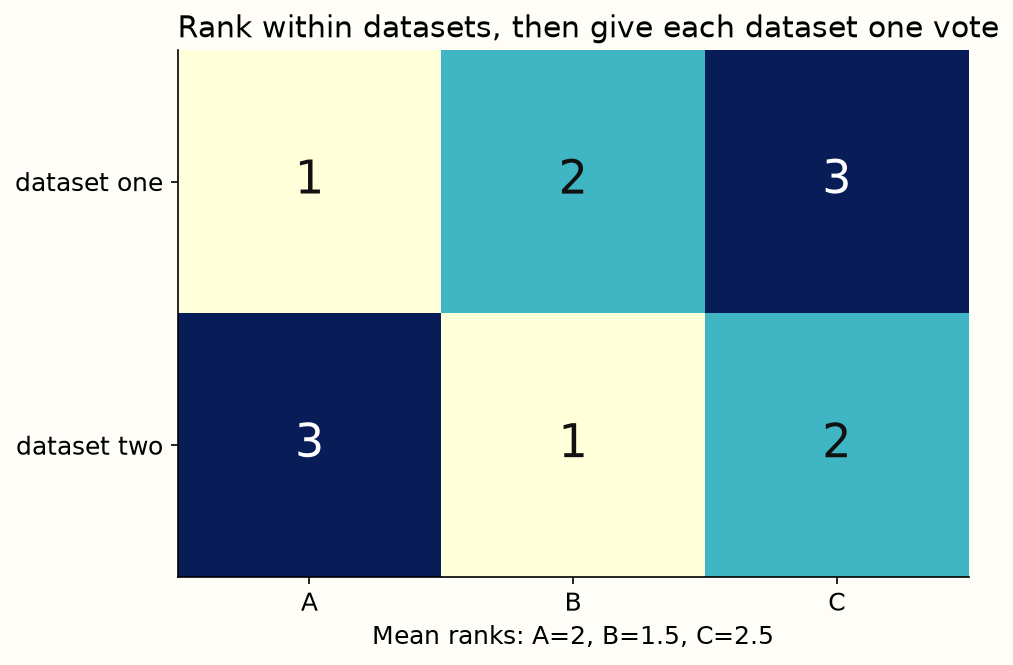</div>

*L058 mechanism: worked computation; see adjacent explanation. Scroll wide figures horizontally on small screens.*

## Make selection bias visible

Before viewing the result, predict what happens if we choose the 45 datasets where XGBoost has the largest rank advantage over the MLP. We have changed the evaluation population using the outcomes. The resulting rank table answers “how do these methods compare on the selected tasks?” It does not independently confirm that those tasks represent future deployment.

The lab performs this deliberately biased selection next to the full 300-dataset analysis. TALENT's compact benchmark construction is useful precisely when its selection objective is understood; reusing an outcome-selected subset to validate the same favored property requires care. For a new model, preregister an additional evaluation population or validate that the subset preserves conclusions outside the methods that selected it. [TALENT Section 8](https://arxiv.org/html/2407.00956v3#S8).

<div style="overflow-x:auto;max-width:100%">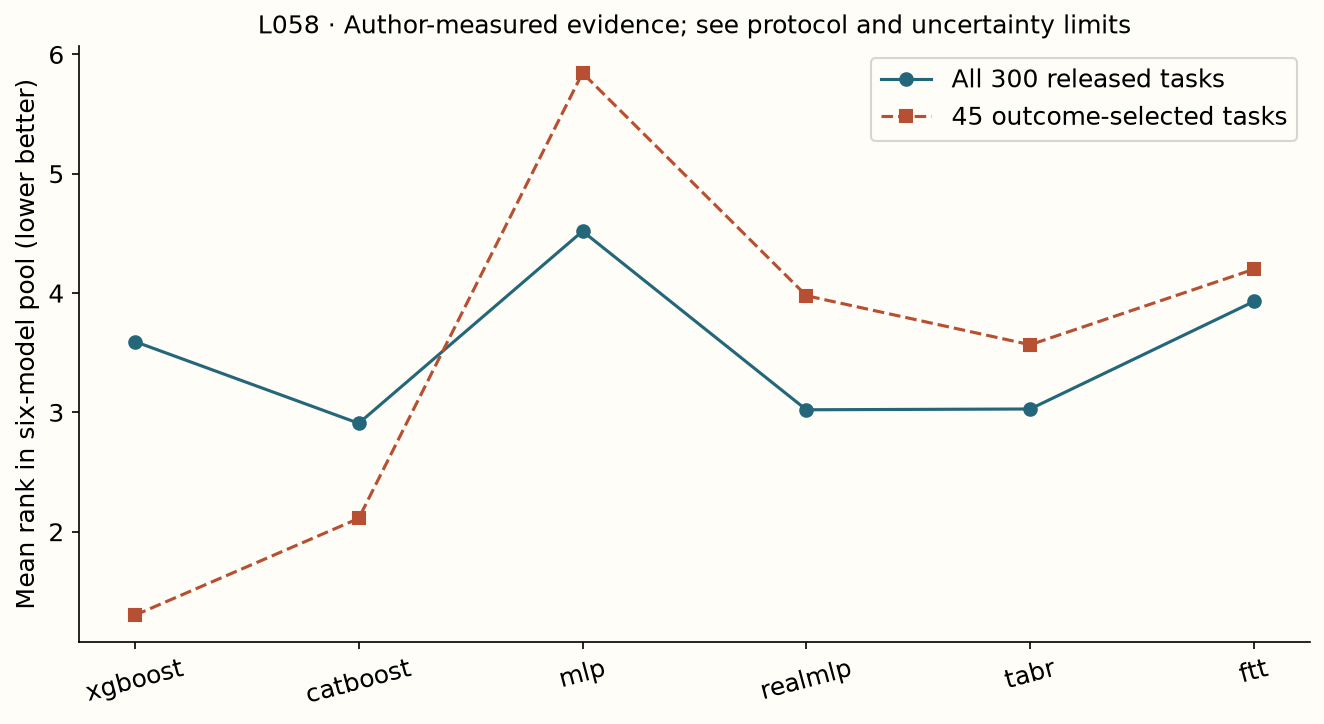</div>

*L058 results: author-reference measurements, separate from your kernel. Scroll wide figures horizontally on small screens.*

## What uncertainty can you recover?

A paired dataset bootstrap samples dataset rows with replacement and recomputes mean ranks for every model on the same sampled rows. Its interval describes sensitivity to this empirical task collection under an exchangeable-dataset approximation. Related tasks, duplicate datasets, and shared source populations weaken that approximation. The procedure cannot reconstruct model-seed uncertainty from rounded published means, and it cannot resolve changes between benchmark versions.

Your evidence card must therefore include source revision, task coverage, score direction, model pool, selection regime, missingness handling, aggregation unit, and one excluded claim. “Six models on 300 historical tasks, complete-case rank reanalysis” is defensible. “We reproduced the paper's full leaderboard” is not the same claim.

### Published mean and SD do not recover paired runs

Two models may each have mean loss 0.4 and SD 0.02 across seeds. That does not tell you the SD of their paired difference. If their errors move together across seeds, the difference can be stable; if they move in opposite directions, it can vary much more. The covariance is missing from the marginal summaries.

The variance identity is Var(A−B)=Var(A)+Var(B)−2Cov(A,B). Without the paired observations or an additional assumption, you cannot recover the covariance. Do not simulate arbitrary seed values from the reported means and SDs and then treat them as observed evidence.

A dataset bootstrap on the parsed mean-score matrix answers a different question. It resamples observed dataset rows jointly across model columns and measures how the aggregate changes with the task mix. It conditions on the reported means as the available observations. It does not restore training-seed uncertainty that the source table did not provide.

With a small or highly related task collection, bootstrap intervals can underrepresent uncertainty about genuinely new domains. State the resampling unit and the population you are willing to generalize to. A confidence interval is meaningful only together with the experiment and assumptions that generated it.

For the exit artifact, retain the pinned source identity, parser checks, complete-panel task IDs, selection rule and bootstrap seed. Then write one conclusion the reconstructed table supports and one it cannot support. This is the bridge from reading a survey to designing a defensible experiment.

## Exit: choose the next experiment

Submit the coverage audit, full and outcome-selected rank tables, paired dataset intervals, and your family map. Write a four-sentence recommendation for lesson 60: which baselines to retain, which deployment regime to test, which evidence is stale or incomplete, and what result would change your choice. Do not choose a relational baseline solely because its single-table rival did poorly on a selected subset.

## Reproduction contract and task support

The visible code below implements the named operator or reduced architecture. The full pretrained model is a separately pinned reference path. Real public-table experiments use Tier A data; synthetic coin/SCM/shift tasks are Tier C mechanism isolation. Seeds, row identities, recipe budgets, versions and source/checkpoint hashes are available in the linked contract and evidence. Numerical agreement with a local operator is not a paper-table reproduction.

In [ ]:
# PROVIDED — environment, peripheral data/metric utilities
import os, sys, math, copy, re, json, hashlib, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch import nn
from scipy.stats import rankdata, friedmanchisquare, studentized_range, t
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.model_selection import StratifiedKFold
from threadpoolctl import threadpool_limits
from IPython.display import display
for directory in [Path.cwd(), Path.cwd()/'labs', Path.cwd().parent]:
    if (directory/'relkit').is_dir():
        ROOT=directory.resolve(); sys.path.insert(0,str(ROOT)); break
else:
    raise RuntimeError('Run the Colab bootstrap or start in the course repository')
torch.set_num_threads(1)
from relkit.foundation_benchmark import random_task, encode_train
print('CPU mechanism track; official checkpoint reruns use an isolated subprocess after EXIT.')

In [ ]:
# PROVIDED — survey_audit; inspect the live function calls
def survey_audit():
    arms=['xgboost','catboost','mlp','realmlp','tabr','ftt']
    tables={};ranks=[];coverage={};dataset_rows=[]
    for task,file in [('binary','cls_bin.md'),('multiclass','cls_multi.md'),('regression','regression.md')]:
        frame=parse_talent(ROOT/'sources/l058'/file)[arms]
        complete=frame.dropna();coverage[task]=dict(released=len(frame),complete=len(complete),excluded=frame.index[frame.isna().any(axis=1)].tolist())
        values=complete.to_numpy();rr=np.array([rankdata(v if task=='regression' else -v) for v in values])
        ranks.extend(rr);dataset_rows.extend(dict(dataset=n,task=task,ranks=dict(zip(arms,r.tolist()))) for n,r in zip(complete.index,rr))
        tables[task]=dict(zip(arms,rr.mean(0).tolist()))
    ranks=np.array(ranks);interval=dataset_bootstrap(ranks)
    # Deliberately outcome-selected subset. This is an illustration of selection bias.
    subset=np.argsort(ranks[:,0]-ranks[:,2])[:45]
    return dict(scope='Frozen TALENT result reanalysis; no training or seed-level data',arms=arms,coverage=coverage,
        datasets=len(ranks),per_task_ranks=tables,mean_ranks=dict(zip(arms,ranks.mean(0).tolist())),
        bootstrap_t95=interval.tolist(),xgb_favored_45_ranks=dict(zip(arms,ranks[subset].mean(0).tolist())),
        dataset_rows=dataset_rows,verdict='INCOMPARABLE',
        limitation='Current released rounded means, six-method pool, complete cases; not the full paper ranking or current corrected benchmark')

## TODO 1 · parse_talent

**Goal:** Parse the pinned markdown mean+SD table into a dataset-indexed numeric frame. Preserve missing values; never turn them into zero.

**Why it matters:** a wrong implementation can produce a plausible-looking experiment while violating this lesson's prediction contract. Before coding, name one input that should fail or one intervention that should leave the result unchanged.

**Hint boundary:** reason from the worked example and the function contract; the CHECK verifies behavior, not a required code layout.

In [ ]:
# TODO 1 — parse_talent
def parse_talent(path):
    raise NotImplementedError("Implement the stated operation")

In [ ]:
# CHECK 1 — parse_talent
frame=parse_talent(ROOT/'sources/l058/cls_bin.md')
assert len(frame)==120, 'Release coverage changed: inspect the pinned source before changing this expectation'
assert abs(frame.loc['Pima_Indians_Diabetes_Database','xgboost']-.7645)<1e-12, 'Mean parsing lost a sign, decimal or emphasis marker'
assert frame.index.is_unique, 'Do not hide duplicate dataset identities'

print("PASS: parse_talent")

## TODO 2 · dataset_bootstrap

**Goal:** Resample whole dataset rows jointly across models and return the 2.5%/97.5% quantiles of mean scores.

**Why it matters:** a wrong implementation can produce a plausible-looking experiment while violating this lesson's prediction contract. Before coding, name one input that should fail or one intervention that should leave the result unchanged.

**Hint boundary:** reason from the worked example and the function contract; the CHECK verifies behavior, not a required code layout.

In [ ]:
# TODO 2 — dataset_bootstrap
def dataset_bootstrap(matrix, draws=1000, seed=58):
    raise NotImplementedError("Implement the stated operation")

In [ ]:
# CHECK 2 — dataset_bootstrap
fixture=np.array([[1.,3.],[2.,2.],[3.,1.]])
interval=dataset_bootstrap(fixture,draws=2000,seed=58)
assert interval.shape==(2,2) and (interval[0]<=interval[1]).all()
np.testing.assert_allclose(interval[:,0],4-interval[::-1,1],atol=1e-12,
                           err_msg='Complementary columns must be sampled on the same dataset indices')

print("PASS: dataset_bootstrap")

## Run your live implementation

Predict the outcome before execution. This cell calls the functions you just wrote. Changing a TODO must change the corresponding computation or make a CHECK fail. The text printed with the result identifies whether this is a small training run, a mechanism test or a reanalysis of committed measurements.

In [ ]:
# PROVIDED — experiment driven by your live functions
trial=survey_audit()
display(pd.DataFrame(trial['coverage']).T)
display(pd.DataFrame({'full':trial['mean_ranks'],'outcome_selected_45':trial['xgb_favored_45_ranks']}))
assert trial['datasets']==300

## Audit author-reference evidence

Inspect the measured results below independently of your smoke experiment. A fresh smoke may use a smaller budget. Preserve the protocol difference rather than forcing numerical agreement with a different run. The committed prediction arrays let you reconstruct scores without downloading pretrained weights.

In [ ]:
# PROVIDED — readable evidence, never impersonating current-kernel training
author=json.loads((ROOT/'_verify_l058_results.json').read_text())
print('AUTHOR REFERENCE:',author.get('scope',author.get('note','Declared checkpoint experiment')))
print('Evidence verdict:',author.get('verdict'))
rows=author.get('records',author.get('summary',[]))
if isinstance(rows,list) and rows:
    display(pd.DataFrame(rows).drop(columns=['predictions','targets','history','context_ids','task_losses'],errors='ignore').head(24))
if 58 in [60,70]:
    for regime,summary in author['summary'].items():
        print(regime,summary['mean_ranks'],'Friedman p=',summary['friedman_p'],'CD=',summary['nemenyi_cd'])

## EXIT TICKET · submit an executable argument

Provide your code output plus a 30–100 word verdict: which implementation ran, what information it could use, what evidence supports the result, and which paper claim remains untested. Include an unexpected or failed case and a next discriminating experiment. The length check below only enforces an attempt; the tutor grades your reasoning. Do not infer personal mastery from a green code cell.

In [ ]:
# TODO — written verdict; paste the resulting artifact and explanation to the tutor
verdict=''
assert len(verdict.split())>=30, 'Write a defensible verdict; a passing code cell is not the explanation'
ticket={'lesson':58,'checks':'passed in this kernel','trial':trial,'verdict':verdict,
        'paper_reproduction':'NOT_ESTABLISHED','author_reference':'_verify_l058_results.json'}
folder=ROOT/'data/cache/foundation';folder.mkdir(parents=True,exist_ok=True)
path=folder/'student-l058-exit.json'
path.write_text(json.dumps(ticket,indent=2,default=lambda x:x.item() if hasattr(x,'item') else x.tolist(),allow_nan=False)+'\n')
print('EXIT artifact:',path)

## NEXT STEP · reproduce or scale the declared track

Read [the exact reproduction contract](l058-reproduction.md) before increasing resources. The gate below invokes the shared runner in a subprocess; historical versions are installed into isolated package directories so v1 and v2 cannot silently replace one another. It may download the pinned checkpoint. Larger runs remain INCOMPARABLE wherever material paper-protocol gaps remain. A full paper preset deliberately fails until the original protocol is implemented.

For unattended CPU execution: `modal run --detach modal/foundation_repro.py --lesson 58 --preset closer`. This is a supplied operator, not evidence that a cloud job was run.

In [ ]:
# PROVIDED — explicit post-EXIT gate (OFF by default)
RUN_PAPER_REPRO=False
if RUN_PAPER_REPRO:
    import subprocess
    subprocess.run([sys.executable,str(ROOT/'_run_foundation.py'),'--lesson','58',
                    '--preset','closer','--output',str(ROOT/'data/cache/foundation/l058-closer.json')],check=True)
else:
    print('Scale-up NOT_RUN in this kernel. See the protocol ledger before enabling.')